---
title: "Chapter 1: Course Introduction"
---

::: {.callout-lo} 

## Learning outcomes {.unnumbered}

From this lecture, you will be able to 

- Explain the difference between Artificial Intelligence (AI), Machine Learning (ML), and Deep Learning (DL) 
- Describe what machine learning is and when it is appropriate to use ML-based solutions.
- Briefly describe supervised learning.
- Differentiate between traditional programming and machine learning.
- Evaluate whether a machine learning solution is suitable for your problem or whether a rule-based or human-expert solution is more appropriate.

:::

**Imports**

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
sys.path.append(os.path.join(os.path.abspath("."), "code"))
from IPython.display import HTML, display
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from img_classify import classify_image

plt.rcParams["font.size"] = 16
pd.set_option("display.max_colwidth", 200)

%matplotlib inline

DATA_DIR = 'data/' 

In [21]:
# Make sure you're using the correct virtual environment. 
import sys
sys.executable

# '/Users/kvarada/CS/2026-27/cpsc330-book/.venv/bin/python'

'/Users/kvarada/CS/2026-27/cpsc330-book/.venv/bin/python'

<br><br>

**Meet Eva, a fictitious student**

![](img/eva-hi.png)

Eva may have a lot in common with you. She has some Python experience and has heard machine learning discussed as a buzzword. During a recent internship, she encountered a messy problem that seemed as though it might benefit from ML. But she did not know how to tell whether ML was the right tool, what data she would need, or whether she could trust the result.

Eva is curious and asks many questions. We will return to her questions throughout the course as she learns to move from a real-world problem to a responsible ML prototype.

<br><br>

## What are AI, ML, and DL?

To begin opening the black box, let's distinguish three terms you have probably heard: AI, ML, and DL. 

- **Artificial Intelligence (AI)**: Helps computers make predictions or decisions when there isn't a simple set of rules. **Examples:** [Deep Blue](https://www.ibm.com/history/deep-blue), early spell checkers
  
- **Machine Learning (ML)**: A subset of AI where systems learn patterns from data instead of being explicitly programmed. **Examples:** Spam filtering in Gmail 

- **Deep Learning (DL)**: A subset of ML that uses multi-layered neural networks to learn complex patterns. **Examples:** image classification, speech-to-text
  
![](img/ai-ml-dl.png)

In this course, we'll focus on machine learning, the practical, everyday workhorse of AI. Toward the end, you'll also get a high-level overview of deep learning, the driver behind recent breakthroughs in generative AI.

<br><br><br><br>

## Why machine learning (ML)? [[video](https://www.youtube.com/watch?v=-1hTcS5ZE4w&t=1s)]

::: {.callout-tip title="See also"}
Check out [the accompanying video](https://www.youtube.com/watch?v=-1hTcS5ZE4w&t=1s) on this material. 
:::

### When is machine learning a useful approach?

Machine learning is especially useful when we have many examples and expect useful patterns in them, but the relationship is too complicated, noisy, or changeable to express as a reliable set of hand-written rules. Image recognition, spam filtering, and personalized recommendations all have this character.

ML is not automatically the right tool for every problem:

- Use **explicit rules** when the logic is known, stable, and deterministic.
- Use **human judgment** when the task depends heavily on context, empathy, values, or accountability.
- Consider **machine learning** when useful rules are difficult to specify but representative data and a meaningful way to evaluate errors are available.

Real systems often combine all three. Before building a model, we should ask what role—if any—ML ought to play and what the consequences of its mistakes would be.

### The big idea

Many modern AI systems are not magic. **They learn patterns from examples.**

Let's build some intuition for this idea before describing it formally.

### Learning patterns in images {.smaller}

Imagine that we want to write a program that can tell cats and foxes apart. What patterns might help?

![](img/cat-or-fox.png) 

| Image ID | Whiskers Present | Ear Size  | Face Shape | Fur Color  | Eye Shape   | Label |
|----------|------------------|-----------|------------|------------|-------------|-------|
| 1        | Yes              | Large     | Round      | Mixed      | Round       | Cat   |
| 2        | Yes              | Medium    | Round      | Brown      | Almond      | Cat   |
| 3        | Yes              | Large     | Pointed    | Red        | Narrow      | Fox   |
| 4        | Yes              | Large     | Pointed    | Red        | Narrow      | Fox   |
| 5        | Yes              | Small     | Round      | Mixed      | Round       | Cat   |
| 6        | Yes              | Large     | Pointed    | Red        | Narrow      | Fox   |
| 7        | Yes              | Small     | Round      | Grey       | Round       | Cat   |
| 8        | Yes              | Small     | Round      | Black      | Round       | Cat   |
| 9        | Yes              | Large     | Pointed    | Red        | Narrow      | Fox   |

Which patterns would you use to classify a new image?

In this small dataset, **fur colour, face shape, and eye shape seem informative**: the foxes have red fur, pointed faces, and narrow eyes, whereas the cats tend to have non-red fur and rounder faces and eyes. **Whiskers are not informative here** because every example has them; a feature that does not vary cannot help distinguish the two classes. Ear size may provide some information, but it does not separate the classes perfectly because some cats also have large ears.

These are patterns in the observed examples, not universal rules about all cats and foxes. More varied data could reveal exceptions or different useful patterns.

::: {.callout-note}
The table uses human-interpretable features to develop intuition. Modern image classifiers usually learn useful representations directly from pixel values.
:::

### Learning patterns in preferences

Imagine that you want to recommend a movie to Pat. Based on these examples, what would you recommend?

![](img/toy-movie-pattern.png)

What pattern connects Sam's and Pat's preferences? How confident are you in your recommendation?

Sam and Pat both rate *The Lion King*, *The Little Mermaid*, and *Bambi* highly, suggesting that their movie preferences may be similar. Because Sam also likes *Toy Story*, it could be a reasonable recommendation for Pat. This is the basic intuition behind **collaborative filtering**: interactions from people with similar preferences can help fill in a missing preference. Recommendation systems often combine this idea with information about the items or users, so they do not fit neatly into only one learning category.

Our confidence should be limited, however: the pattern is based on only a few overlapping ratings, and we know very little about the other factors that shape either person's preferences.

### Learning patterns in language

Suppose you are given these examples. **How would you build a spam detector?**

| Message | Spam? |
|:--------|:-----:|
| 🎉 CONGRATULATIONS! YOU WON $1000! | ✓ |
| Your package has shipped | ✗ |
| Assignment due tomorrow | ✗ |
| YOU WON A FREE PRIZE 🎁! | ✓ |
| Dinner tonight? | ✗ |
| Can we meet at 3 PM? | ✗ |

- What patterns do you notice?
- Which patterns might be misleading?
- How would you test whether your detector works on new messages?

In these examples, spam is associated with phrases such as **“YOU WON”** and **“FREE PRIZE,”** mentions of money, celebratory emoji, and extensive capitalization. The non-spam messages use more ordinary conversational or informational language. These cues may help on this dataset, but none is a universal rule: legitimate promotions can mention prizes, and genuine messages can use capital letters or emoji. A reliable detector would need more varied examples and evaluation on messages it did not learn from.

### Learning patterns without labels

Suppose we have a large collection of food photographs but no category labels. How might you organize these images into useful groups?

![](img/food-clustering-activity.png){fig-alt="A collage of many foods, including desserts, pasta, salads, soup, and breakfast dishes"}

A **clustering** method looks for groups of similar examples without being told the correct group for each image. To do this, we first need a numerical **representation** of each image—perhaps features learned by a neural network—and a way to describe which representations are similar. The method might then group foods by visual appearance, ingredients, cuisine, or some other pattern encoded by that representation. Unlike cat-versus-fox classification, there is no supplied target label and often no single correct grouping.

The resulting clusters do not explain themselves. People must examine and interpret them—and check whether the discovered grouping is useful or merely reflects incidental features such as plate colour, lighting, or background.

### One recurring idea

These systems all learn from examples:

- Image classifiers learn patterns in visual information.
- Recommenders learn patterns in preferences and interactions.
- Spam filters learn patterns in language.
- Clustering methods look for structure among examples that do not have labels.

The data and methods differ, but the goal is similar: **learn from observed examples and generalize to new cases.**

::: {.callout-caution}
A learned pattern is not necessarily meaningful or reliable. It may reflect accidents or biases in the training data.
:::

<br><br>

## A map of the course

The course studies several ways of learning from data and follows them through the broader problem-solving workflow.

| Course component | Guiding question | Examples |
|---|---|---|
| **Supervised learning** | Can labeled examples help us predict a target for a new case? | Spam detection, disease prediction, house-price prediction |
| **Unsupervised learning and recommendations** | What structure or preferences can we discover when the desired answer is not directly supplied? | Clustering foods or customers, recommending movies |
| **Different kinds of data** | How should the representation and method change with the data? | Images, text, time series, and right-censored data |
| **Communication, ethics, and deployment** | Does the system serve the real-world goal, and how should we describe and monitor its limitations? | Error analysis, fairness, explanations, deployment and monitoring |

We will begin with supervised learning because it provides a concrete setting in which to introduce the vocabulary, workflow, and evaluation habits that recur throughout the course.

## Supervised machine learning

### What is supervised machine learning (ML)? 

- Training data comprises a set of observations ($X$) and their corresponding targets ($y$). 
- We wish to find a model function $f$ that relates $X$ to $y$.
- We use the model function to predict targets of new examples. 

![](img/sup-learning.png)

<!-- <img src="../img/sup-learning.png" height="600" width="600">  -->


### Example: Predict whether a message is spam or not 

#### Input features $X$ and target $y$

::: {.callout-note}
Do not worry about the code and syntax for now. 
:::

::: {.callout-note}
Download SMS Spam Collection Dataset from [here](https://www.kaggle.com/uciml/sms-spam-collection-dataset). 
:::

#### Training a supervised machine learning model with $X$ and $y$

In [22]:
sms_df = pd.read_csv(DATA_DIR + "spam.csv", encoding="latin-1")
sms_df = sms_df.drop(columns = ["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"])
sms_df = sms_df.rename(columns={"v1": "target", "v2": "sms"})
train_df, test_df = train_test_split(sms_df, test_size=0.10, random_state=42)
HTML(train_df.head().to_html(index=False))

target,sms
spam,"LookAtMe!: Thanks for your purchase of a video clip from LookAtMe!, you've been charged 35p. Think you can do better? Why not send a video in a MMSto 32323."
ham,"Aight, I'll hit you up when I get some cash"
ham,Don no da:)whats you plan?
ham,Going to take your babe out ?
ham,No need lar. Jus testing e phone card. Dunno network not gd i thk. Me waiting 4 my sis 2 finish bathing so i can bathe. Dun disturb u liao u cleaning ur room.


In [23]:
X_train, y_train = train_df["sms"], train_df["target"]
X_test, y_test = test_df["sms"], test_df["target"]
clf = make_pipeline(CountVectorizer(max_features=5000), LogisticRegression(max_iter=5000))
clf.fit(X_train, y_train);

#### Predicting on unseen data using the trained model

In [24]:
pd.DataFrame(X_test[0:4])

,sms
3245,"Funny fact Nobody teaches volcanoes 2 erupt, tsunamis 2 arise, hurricanes 2 sway aroundn no 1 teaches hw 2 choose a wife Natural disasters just happens"
944,"I sent my scores to sophas and i had to do secondary application for a few schools. I think if you are thinking of applying, do a research on cost also. Contact joke ogunrinde, her school is one m..."
1044,"We know someone who you know that fancies you. Call 09058097218 to find out who. POBox 6, LS15HB 150p"
2484,Only if you promise your getting out as SOON as you can. And you'll text me in the morning to let me know you made it in ok.


::: {.callout-note}
Do not worry about the code and syntax for now. 
:::

In [25]:
pred_dict = {
    "sms": X_test[0:4],
    "spam_predictions": clf.predict(X_test[0:4]),
}
pred_df = pd.DataFrame(pred_dict)
pred_df.style.set_properties(**{"text-align": "left"})

,sms,spam_predictions
3245,"Funny fact Nobody teaches volcanoes 2 erupt, tsunamis 2 arise, hurricanes 2 sway aroundn no 1 teaches hw 2 choose a wife Natural disasters just happens",ham
944,"I sent my scores to sophas and i had to do secondary application for a few schools. I think if you are thinking of applying, do a research on cost also. Contact joke ogunrinde, her school is one me the less expensive ones",ham
1044,"We know someone who you know that fancies you. Call 09058097218 to find out who. POBox 6, LS15HB 150p",spam
2484,Only if you promise your getting out as SOON as you can. And you'll text me in the morning to let me know you made it in ok.,ham


**We have accurately predicted labels for the unseen text messages above!**

<br><br>

### (Supervised) machine learning: popular definition 
<blockquote>
A field of study that gives computers the ability to learn without being explicitly programmed. <br> -- Arthur Samuel (1959)
</blockquote>

ML is a different way to think about problem solving.

![](img/traditional-programming-vs-ML.png)
<!-- <img src="img/traditional-programming-vs-ML.png" height="700" width="700">  -->

### Examples

Let's look at some concrete examples of supervised machine learning. 

::: {.callout-note}
Do not worry about the code at this point. Just focus on the input and output in each example.
:::

#### Example 1: Predicting whether a patient has a liver disease or not

##### Input data

Suppose we are interested in predicting whether a patient has the disease or not. We are given some tabular data with inputs and outputs of liver patients, as shown below. The data contains a number of input features and a special column called "Target" which is the output we are interested in predicting. 

::: {.callout-note}
Download the data from [here](https://www.kaggle.com/uciml/indian-liver-patient-records). 
:::

In [26]:
df = pd.read_csv(DATA_DIR + "indian_liver_patient.csv")
df = df.drop(columns = ["Gender"])
df["Dataset"] = df["Dataset"].replace(1, "Disease")
df["Dataset"] = df["Dataset"].replace(2, "No Disease")
df.rename(columns={"Dataset": "Target"}, inplace=True)
train_df, test_df = train_test_split(df, test_size=4, random_state=42)
HTML(train_df.head().to_html(index=False))

Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Target
40,14.5,6.4,358,50,75,5.7,2.1,0.50,Disease
33,0.7,0.2,256,21,30,8.5,3.9,0.80,Disease
24,0.7,0.2,188,11,10,5.5,2.3,0.71,No Disease
60,0.7,0.2,171,31,26,7.0,3.5,1.00,No Disease
18,0.8,0.2,199,34,31,6.5,3.5,1.16,No Disease


##### Building a supervise machine learning model

Let's train a supervised machine learning model with the input and output above. 

In [27]:
from lightgbm.sklearn import LGBMClassifier

X_train = train_df.drop(columns=["Target"])
y_train = train_df["Target"]
X_test = test_df.drop(columns=["Target"])
y_test = test_df["Target"]
model = LGBMClassifier(random_state=123, verbose=-1,  n_jobs=1)
model.fit(X_train, y_train)

,random_state,123
,n_jobs,1
,verbose,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None


##### Model predictions on unseen data

- Given features of new patients below we'll use this model to predict whether these patients have the liver disease or not. 

In [28]:
HTML(X_test.reset_index(drop=True).to_html(index=False))

Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio
19,1.4,0.8,178,13,26,8.0,4.6,1.30
12,1.0,0.2,719,157,108,7.2,3.7,1.00
60,5.7,2.8,214,412,850,7.3,3.2,0.78
42,0.5,0.1,162,155,108,8.1,4.0,0.90


In [29]:
pred_df = pd.DataFrame({"Predicted_target": model.predict(X_test).tolist()})

df_concat = pd.concat([pred_df, X_test.reset_index(drop=True)], axis=1)
HTML(df_concat.to_html(index=False))

Predicted_target,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio
No Disease,19,1.4,0.8,178,13,26,8.0,4.6,1.30
Disease,12,1.0,0.2,719,157,108,7.2,3.7,1.00
Disease,60,5.7,2.8,214,412,850,7.3,3.2,0.78
Disease,42,0.5,0.1,162,155,108,8.1,4.0,0.90


<br><br>

#### Example 2: Predicting the label of a given image 

Suppose you want to predict the label of a given image using supervised machine learning. We are using a pre-trained model here to predict labels of new unseen images. 

In [30]:
import glob

import matplotlib.pyplot as plt
from PIL import Image

images = glob.glob(DATA_DIR + "test_images/*.*")

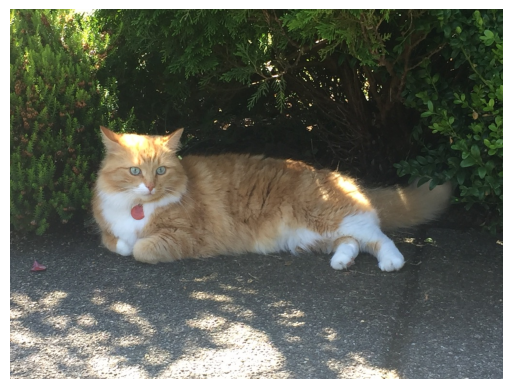

      Class  Probability score
  tiger cat              0.276
Persian cat              0.275
   Pembroke              0.251
      tabby              0.095
------------------------------------------------------------


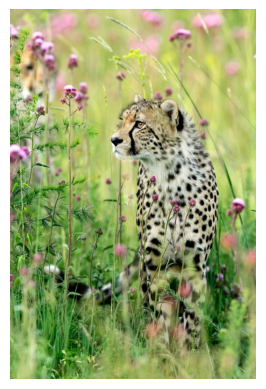

       Class  Probability score
     cheetah              0.973
     leopard              0.024
      jaguar              0.002
snow leopard              0.001
------------------------------------------------------------


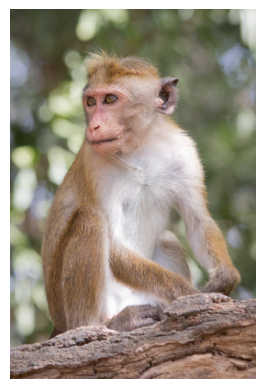

   Class  Probability score
 macaque              0.873
   patas              0.052
  langur              0.033
capuchin              0.011
------------------------------------------------------------


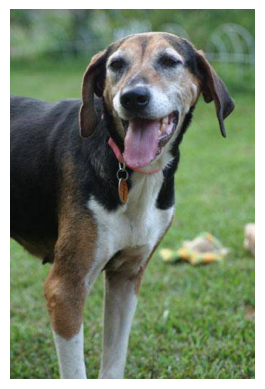

                     Class  Probability score
               EntleBucher              0.237
Greater Swiss Mountain dog              0.235
                    beagle              0.162
               Appenzeller              0.152
------------------------------------------------------------


In [31]:
for image_path in images:
    image = Image.open(image_path).convert("RGB")

    plt.imshow(image)
    plt.axis("off")
    plt.show()

    predictions = classify_image(image_path)

    print(predictions.to_string(index=False))
    print("-" * 60)

<br><br>

#### Example 3: Text classification with a pretrained language model

A **large language model (LLM)** is trained on a very large collection of text and can be adapted or prompted for many language tasks. Instead of training a sentiment classifier from scratch on movie reviews, we can start with a pretrained model that has already been fine-tuned to classify text as positive or negative.

Here, a Hugging Face `pipeline` handles tokenization, model inference, and conversion of the model output into a label and confidence score.

In [32]:
#| eval: false
from transformers import pipeline

sentiment_analyzer = pipeline(
    task="sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
)

texts = [
    "I asked my model to predict my future, and it said '404: Life not found.'",
    "Machine learning is like cooking: sometimes you follow the recipe, and sometimes you hope for the best!",
]
sentiment_analyzer(texts)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'NEGATIVE', 'score': 0.995707631111145},
 {'label': 'POSITIVE', 'score': 0.9992092251777649}]

The result is one dictionary per text containing a predicted `label`—here `POSITIVE` or `NEGATIVE`—and a `score`. Notice what changed from the earlier examples: we did not collect and label a new sentiment dataset or fit a model in this notebook. We reused a model trained elsewhere.

::: {.callout-note title="Why isn't this cell executed while building the book?"}
The first run downloads the pretrained model. Keeping this example non-executing makes the book build reproducible in offline and resource-constrained environments. You can run it interactively after installing the project dependencies and allowing the model download.
:::

##### Going beyond the model's original labels: zero-shot classification

The sentiment model above is restricted to the labels it was trained to predict. Suppose instead that we want to classify text using our own candidate emotion labels—without first providing labeled examples for this particular task. A pretrained model designed for **zero-shot classification** can score how well each candidate label fits the text.

In [33]:
#| eval: false
from transformers import pipeline

emotion_classifier = pipeline(
    task="zero-shot-classification",
    model="facebook/bart-large-mnli",
)

text = "I submitted the assignment after weeks of work, and it finally passed every test."
candidate_labels = ["sadness", "joy", "love", "anger", "fear", "surprise"]
emotion_classifier(text, candidate_labels)

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

{'sequence': 'I submitted the assignment after weeks of work, and it finally passed every test.',
 'labels': ['surprise', 'joy', 'anger', 'fear', 'sadness', 'love'],
 'scores': [0.4165930449962616,
  0.3298921585083008,
  0.08962558954954147,
  0.06469517946243286,
  0.05273403599858284,
  0.04646006599068642]}

The classifier returns all candidate labels ranked by score. Calling this *zero-shot* does not mean the model learned from no data: it was pretrained on substantial data, but it was not trained on labeled examples from this exact emotion-classification task.

This flexibility is powerful, but the output is still a prediction, not an objective reading of a person's internal state. Results depend on the wording, candidate labels, training data, and context available to the model. We still need suitable evaluation data before deciding whether the classifier is useful for a real application.

<br><br>

#### Example 4: Predicting housing prices

Suppose we want to predict housing prices given a number of attributes associated with houses. 

::: {.callout-note}
Download the data from [here](https://www.kaggle.com/harlfoxem/housesalesprediction). 
:::

In [34]:
df = pd.read_csv( DATA_DIR + "kc_house_data.csv")
df = df.drop(columns = ["id", "date"])
df.rename(columns={"price": "target"}, inplace=True)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=4)
HTML(train_df.head().to_html(index=False))

target,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
509000.0,2,1.50,1930,3521,2.0,0,0,3,8,1930,0,1989,0,98007,47.6092,-122.146,1840,3576
675000.0,5,2.75,2570,12906,2.0,0,0,3,8,2570,0,1987,0,98075,47.5814,-122.050,2580,12927
420000.0,3,1.00,1150,5120,1.0,0,0,4,6,800,350,1946,0,98116,47.5588,-122.392,1220,5120
680000.0,8,2.75,2530,4800,2.0,0,0,4,7,1390,1140,1901,0,98112,47.6241,-122.305,1540,4800
357823.0,3,1.50,1240,9196,1.0,0,0,3,8,1240,0,1968,0,98072,47.7562,-122.094,1690,10800


In [35]:
# Build a regression model
from lightgbm.sklearn import LGBMRegressor

X_train, y_train = train_df.drop(columns= ["target"]), train_df["target"]
X_test, y_test = test_df.drop(columns= ["target"]), train_df["target"]

model = LGBMRegressor(random_state=123, verbose=-1, n_jobs=1)
#model = XGBRegressor()
model.fit(X_train, y_train);

In [36]:
# Predict on unseen examples using the built model
pred_df = pd.DataFrame(
    # {"Predicted target": model.predict(X_test[0:4]).tolist(), "Actual price": y_test[0:4].tolist()}
    {"Predicted_target": model.predict(X_test[0:4]).tolist()}
)
df_concat = pd.concat([pred_df, X_test[0:4].reset_index(drop=True)], axis=1)
HTML(df_concat.to_html(index=False))

Predicted_target,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
345831.740542,4,2.25,2130,8078,1.0,0,0,4,7,1380,750,1977,0,98055,47.4482,-122.209,2300,8112
601042.018745,3,2.50,2210,7620,2.0,0,0,3,8,2210,0,1994,0,98052,47.6938,-122.130,1920,7440
311310.186024,4,1.50,1800,9576,1.0,0,0,4,7,1800,0,1977,0,98045,47.4664,-121.747,1370,9576
597555.592401,3,2.50,1580,1321,2.0,0,2,3,8,1080,500,2014,0,98107,47.6688,-122.402,1530,1357


These examples show that supervised learning can work with many kinds of data and targets. But a problem *can* be expressed as a prediction task without ML necessarily being the right solution. Problem framing comes first.
- Use machine learning when you have a large, complex dataset and the decision rules are unknown, fuzzy, or too complicated to define explicitly.
- Pause before jumping in: ML is exciting, but always ask whether you really need it for your problem.
- Use rule-based systems when the logic is clear, deterministic, and based on stable rules or thresholds.
- Rely on human expertise when problems involve ethics, creativity, emotion, or ambiguity that cannot be formalized easily.

<br><br>

### 🤔 Eva's questions

The examples produced predictions, but they also exposed more of the work hidden inside the black box. Eva is now wondering:

- How are we exactly "learning" whether a message is spam and ham? 
- What do you mean by "learn without being explicitly programmed"? The code has to be somewhere ... 
- Are we expected to get correct predictions for all possible messages? How does it predict the label for a message it has not seen before?  
- What if the model mis-labels an unseen example? For instance, what if the model incorrectly predicts a non-spam as a spam? What would be the consequences? 
- How do we measure the success or failure of spam identification? 
- If you want to use this model in the wild, how do you know how reliable it is?  
- Would it be useful to know how confident the model is about the predictions rather than just a yes or a no?

These are not side questions—they are central to applied machine learning. By the end of the course, you will have a practical framework for answering many of them.  

![](img/eva-qm.png)

### Supervised machine learning workflow 

Supervised machine learning is quite flexible; it can be used on a variety of problems and different kinds of data. Here is a typical workflow of a supervised machine learning systems.  

![](img/ml-workflow.png)

<!-- <img src="img/ml-workflow.png" height="800" width="800">  -->

A model is only one part of an ML solution. Throughout this course, we will revisit this workflow: frame the problem, examine the data, build and evaluate a model, study its limitations, and communicate what the results do—and do not—support. 

<br><br>

### Who or what should solve the problem?

Before choosing a model, ask whether the task is better suited to a human, an explicit set of rules, or a system that learns patterns from data.

| Best starting point | Example problems | Why? |
|---|---|---|
| **Human judgment** | Giving a student feedback on a personal essay; deciding how to support a patient after a difficult diagnosis; resolving an unusual dispute between two people | The task depends on context, empathy, values, or accountability. There may be no single correct answer. |
| **Rule-based system** | Checking whether an email address ends in `@student.ubc.ca`; calculating sales tax; rejecting a password shorter than 12 characters | The rules are known, stable, easy to state, and should be applied consistently. |
| **Machine learning system** | Filtering spam; predicting which songs a listener may enjoy; recognizing objects in photographs | Useful patterns exist in data, but writing complete and reliable rules by hand would be difficult. Some errors are expected. |

The boundary is not always sharp. A real system may combine all three: an ML model flags suspicious credit-card transactions, rules automatically block clearly impossible transactions, and a human reviews ambiguous or high-impact cases.

::: {.callout-important}
The fact that ML *can* make a prediction does not mean it should make the final decision. Consider the cost of errors, who is affected, and who should be accountable.
:::

### Try framing an ML problem

Think of a problem that might benefit from machine learning. Before choosing an algorithm, discuss these questions:

1. What would the inputs and desired outputs be?
2. How is the problem handled now? Are there useful human heuristics or explicit rules?
3. What data already exist, and what additional data could reasonably be collected?
4. What kinds of mistakes could the system make, and who would be affected?
5. Would ML support a person, automate part of the process, or make the final decision?

These questions connect model building to the real-world problem it is meant to address.

### ❓❓ Questions for you

### Exercise 1.1

**For each problem, what is the best starting point?**

- **H:** human judgment
- **R:** a rule-based system
- **M:** a machine learning system

Classify each problem as **H**, **R**, or **M**.

1. Checking whether a UBC email address ends with `@student.ubc.ca` before allowing login
2. Giving a student constructive feedback on a personal essay
3. Predicting which songs a listener might enjoy based on their listening history
4. Calculating the shipping fee from a published table of package weights and destinations
5. Recognizing which species of bird appears in a photograph
6. Resolving a disagreement between two project teammates after hearing both perspectives

<br><br>

::: {.callout-note collapse="true"}
## Suggested answers

1. **R** — the condition is explicit and deterministic.
2. **H** — good feedback depends on meaning, goals, context, and care.
3. **M** — preferences involve complex patterns that can be learned from data.
4. **R** — the published table completely specifies the calculation.
5. **M** — visual categories are difficult to describe with exhaustive hand-written rules.
6. **H** — the task requires context, communication, and accountable judgment.

These are starting points, not universal answers. For example, ML might help retrieve relevant writing examples, but a person should remain responsible for personal feedback.
:::

## Summary

- The goal of this course is to open the ML black box and learn how to approach real-world problems from framing through communication.
- Machine learning is useful when patterns must be learned from data; clear, stable logic may be better handled by explicit rules, and some decisions require human judgment.
- In supervised learning, we learn a relationship between observations ($X$) and targets ($y$), then use it to make predictions for unseen examples.
- A trained model is only a prototype component, not a complete solution. We must also evaluate it in context, identify its limitations and possible harms, and communicate what conclusions the evidence supports.

![](img/eva-seeyou.png)